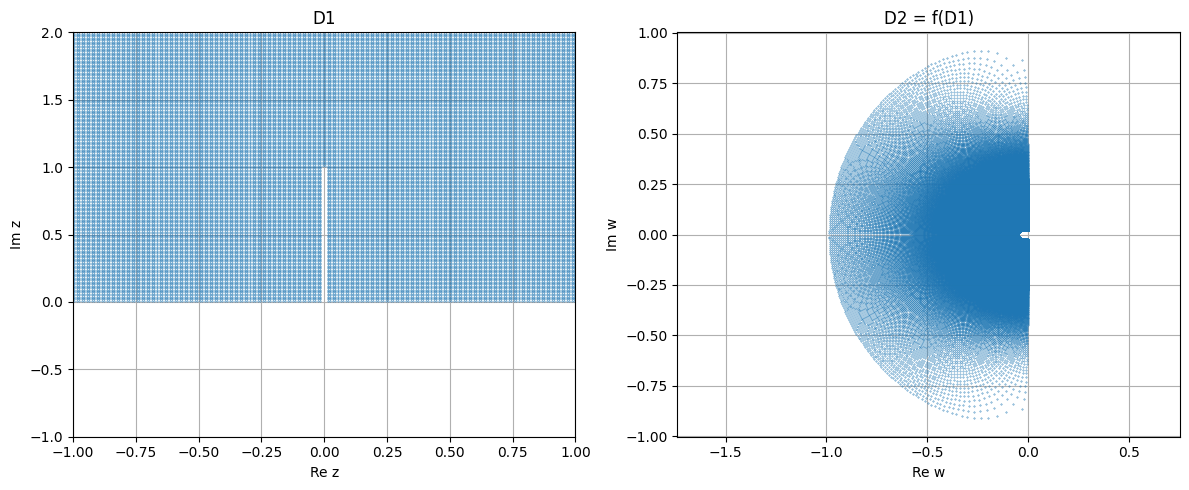

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(z):
    res = np.zeros_like(z, dtype=complex)
    mask = np.real(z) >= 0
    res[mask] = -np.sqrt(z[mask]**2 + 1) + z[mask]
    res[~mask] = -np.sqrt(z[~mask]**2 + 1) - z[~mask]
    return res

x = np.linspace(-10, 10, 2000)
y = np.linspace(0.01, 20, 2000)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

mask_cut = ~((np.abs(X) < 0.01) & (Y <= 1))
Z = Z[mask_cut]

W = f(Z)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(Z.real, Z.imag, s=0.1)
ax.set_xlabel("Re z")
ax.set_ylabel("Im z")
ax.set_title("D1")
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 2])
ax.grid(True)
ax.set_axisbelow(True)

ax = axes[1]
ax.scatter(W.real, W.imag, s=0.1)
ax.set_xlabel("Re w")
ax.set_ylabel("Im w")
ax.set_title("D2 = f(D1)")
ax.grid(True)
ax.set_axisbelow(True)
ax.axis("equal")

plt.tight_layout()
plt.savefig("f.png", dpi=200)

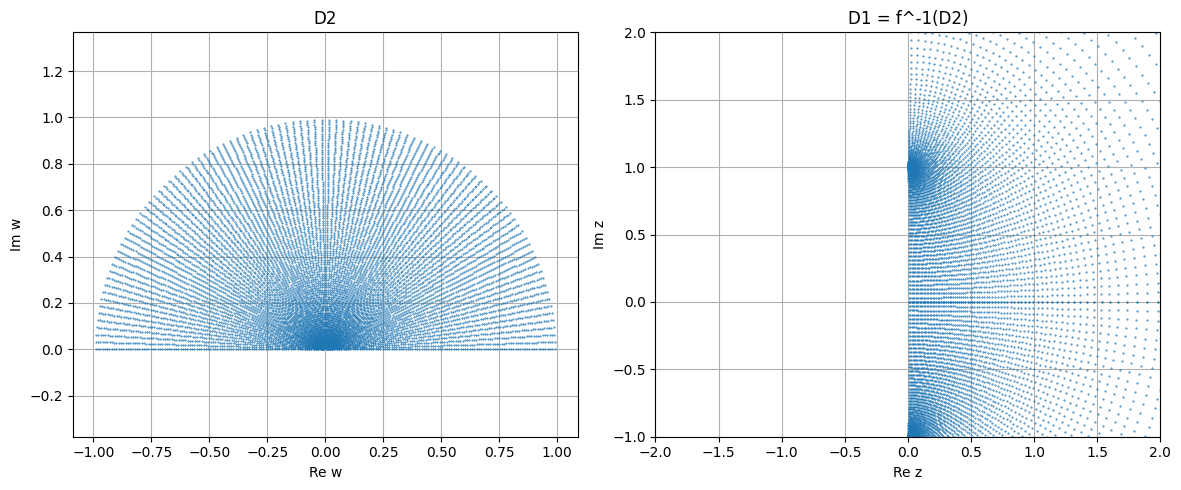

In [2]:
def g(w):
    z = np.sqrt((-0.5 * (w + 1 / w))**2 - 1)
    return z

theta = np.linspace(0, np.pi, 100)
r = np.linspace(0.01, 0.99, 100)
R, T = np.meshgrid(r, theta)
W = R * np.exp(1j * T)

Z = g(W)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(W.real, W.imag, s=0.2)
ax.set_xlabel("Re w")
ax.set_ylabel("Im w")
ax.set_title("D2")
ax.axis("equal")
ax.grid(True)
ax.set_axisbelow(True)

ax = axes[1]
ax.scatter(Z.real, Z.imag, s=0.2)
ax.set_xlabel("Re z")
ax.set_ylabel("Im z")
ax.set_title("D1 = f^-1(D2)")
ax.set_xlim([-2, 2])
ax.set_ylim([-1, 2])
ax.grid(True)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("g.png", dpi=200)